# What Factors Influence What Mitigation Action is Taken Once a Delay Occurs?

### Author
Imran Qureshi

### Notebook Overview
This notebook focuses specifically on predicting mitigation actions taken during shipment disruptions using classification-based analytical techniques in R. The analysis evaluates operational, transportation-related, route-related, and disruption-related variables associated with corrective supply chain responses.


# Exploratory Data Analysis (EDA)

Initial exploratory data analysis was performed to better understand the distributions and variation of shipment-related variables before predictive modeling.


Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Loading required package: lattice

Warning message:
"package 'lattice' was built under R version 4.5.3"

Attaching package: 'kknn'


The following object is masked from 'package:caret':

    contr.dummy


Warning message:
"package 'rpart' was built under R version 4.5.3"
Warning message:
"package 'rpart.plot' was built under R version 4.5.2"
Warning message:
"package 'skimr' was built under R version 4.5.2"
Warning message:
"package 'psych' was built under R version 4.5.3"

Attaching package: 'psych'


The following objects are masked from 'package:ggplot2':

    %+%, alpha




'data.frame':	10000 obs. of  19 variables:
 $ Order_Date              : chr  "1/4/2024" "1/4/2024" "1/4/2024" "1/4/2024" ...
 $ Origin_City             : chr  "Tokyo, JP" "Shanghai, CN" "Santos, BR" "Tokyo, JP" ...
 $ Destination_City        : chr  "Singapore, SG" "Los Angeles, US" "Shanghai, CN" "Singapore, SG" ...
 $ Route_Type              : chr  "Intra-Asia" "Pacific" "Commodity" "Intra-Asia" ...
 $ Transportation_Mode     : chr  "Sea" "Sea" "Sea" "Sea" ...
 $ Product_Category        : chr  "Perishable Foods" "Textiles" "Consumer Electronics" "Perishable Foods" ...
 $ Base_Lead_Time_Days     : int  7 18 35 7 7 28 24 35 7 12 ...
 $ Scheduled_Lead_Time_Days: int  10 19 38 8 10 31 27 37 9 15 ...
 $ Actual_Lead_Time_Days   : int  10 18 35 7 7 27 24 35 7 12 ...
 $ Delay_Days              : int  0 -1 -3 -1 -3 -4 -3 -2 -2 -3 ...
 $ Delivery_Status         : chr  "On Time" "On Time" "On Time" "On Time" ...
 $ Disruption_Event        : chr  "Port Congestion" "None" "None" "None" ...
 $ Geop

   Order_Date         Origin_City        Destination_City        Route_Type 
 Min.   :2024-01-05   Length:1290        Length:1290        Atlantic  :184  
 1st Qu.:2024-07-16   Class :character   Class :character   Commodity :144  
 Median :2024-12-30   Mode  :character   Mode  :character   Intra-Asia:219  
 Mean   :2025-01-03                                         Pacific   :194  
 3rd Qu.:2025-07-10                                         Suez      :549  
 Max.   :2026-01-03                                                         
                                                                            
 Transportation_Mode             Product_Category Base_Lead_Time_Days
 Air: 211            Auto Parts          :189     Min.   : 2.00      
 Sea:1079            Consumer Electronics:178     1st Qu.: 7.00      
                     Perishable Foods    :181     Median :18.00      
                     Pharmaceuticals     :161     Mean   :17.52      
                     Raw Materials

,skim_type,skim_variable,n_missing,complete_rate,Date.min,Date.max,Date.median,Date.n_unique,character.min,character.max,⋯,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<date>,<date>,<date>,<int>,<int>,<int>,⋯,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Date,Order_Date,0,1,2024-01-05,2026-01-03,2024-12-30,611,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,Origin_City,0,1,NA,NA,NA,NA,9,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,character,Destination_City,0,1,NA,NA,NA,NA,12,15,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,character,Delivery_Status,0,1,NA,NA,NA,NA,4,4,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,factor,Route_Type,0,1,NA,NA,NA,NA,NA,NA,⋯,5,"Sue: 549, Int: 219, Pac: 194, Atl: 184",NA,NA,NA,NA,NA,NA,NA,NA
6,factor,Transportation_Mode,0,1,NA,NA,NA,NA,NA,NA,⋯,2,"Sea: 1079, Air: 211",NA,NA,NA,NA,NA,NA,NA,NA
7,factor,Product_Category,0,1,NA,NA,NA,NA,NA,NA,⋯,7,"Tex: 209, Sem: 194, Aut: 189, Per: 181",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,Disruption_Event,0,1,NA,NA,NA,NA,NA,NA,⋯,4,"Por: 524, Geo: 521, Sev: 173, Non: 72",NA,NA,NA,NA,NA,NA,NA,NA
9,factor,Mitigation_Action_Taken,0,1,NA,NA,NA,NA,NA,NA,⋯,3,"Sta: 589, Re-: 368, Exp: 333",NA,NA,NA,NA,NA,NA,NA,NA


Warning message in FUN(newX[, i], ...):
"no non-missing arguments to min; returning Inf"
Warning message in FUN(newX[, i], ...):
"no non-missing arguments to max; returning -Inf"


,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Order_Date,1,1290,NaN,NA,NA,NaN,NA,Inf,-Inf,-Inf,NA,NA,NA
Origin_City*,2,1290,3.546512e+00,1.725029e+00,4.000,3.558140,2.965200,1.00,6.00,5.00,-0.015153645,-1.37943531,4.802878e-02
Destination_City*,3,1290,3.328682e+00,1.767441e+00,3.000,3.285853,2.965200,1.00,6.00,5.00,0.108916230,-1.29040337,4.920962e-02
Route_Type*,4,1290,3.604651e+00,1.473419e+00,4.000,3.755814,1.482600,1.00,5.00,4.00,-0.579513036,-1.10216725,4.102338e-02
Transportation_Mode*,5,1290,1.836434e+00,3.700246e-01,2.000,1.920543,0.000000,1.00,2.00,1.00,-1.817032042,1.30261702,1.030234e-02
Product_Category*,6,1290,4.068992e+00,2.051104e+00,4.000,4.086240,2.965200,1.00,7.00,6.00,-0.041129257,-1.31286179,5.710746e-02
Base_Lead_Time_Days,7,1290,1.752016e+01,1.049681e+01,18.000,17.292636,14.826000,2.00,35.00,33.00,0.007386760,-1.27410427,2.922554e-01
Scheduled_Lead_Time_Days,8,1290,1.942713e+01,1.051253e+01,20.000,19.229651,14.826000,3.00,38.00,35.00,0.005269667,-1.28298642,2.926931e-01
Actual_Lead_Time_Days,9,1290,2.677209e+01,1.296750e+01,24.000,26.864341,19.273800,4.00,49.00,45.00,0.025837822,-1.49469229,3.610449e-01


null device 
          1

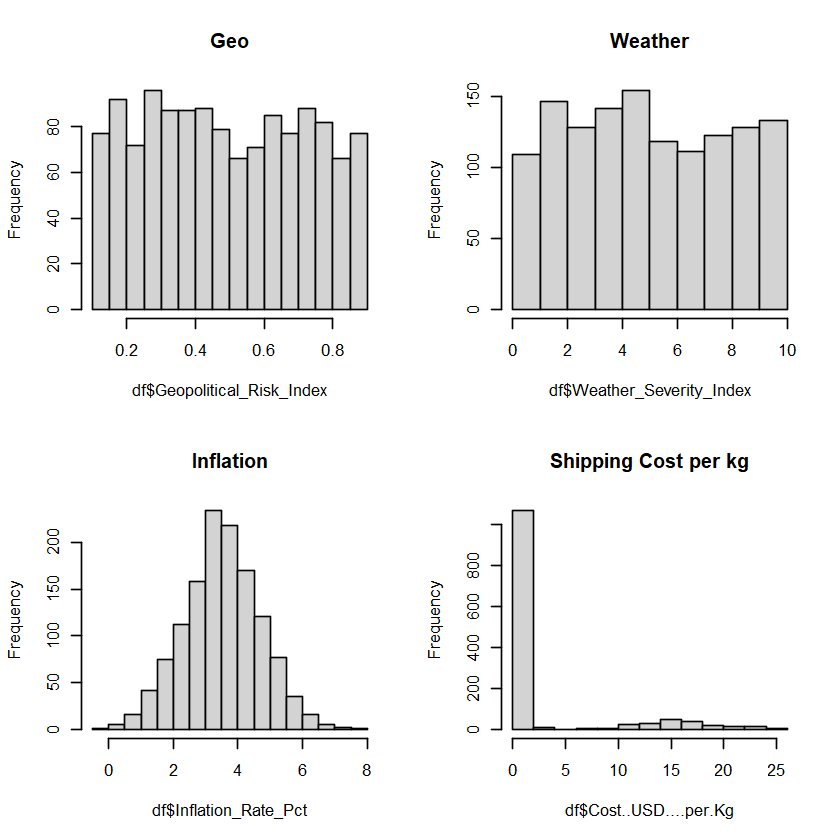

In [1]:
library(caret)
library(kknn)
library(rpart)
library(rpart.plot)
library(skimr)
library(psych)

df <- read.csv("C:/Users/iqure/Downloads/IT 190 Project - Imran Qureshi - Data.csv")
str(df)

df <- df[df$Delivery_Status == "Late", ]
df$Shipping_Cost_USD <- as.numeric(gsub("[^0-9.]", "", df$Shipping_Cost_USD))
df$Cost..USD....per.Kg <- as.numeric(gsub("[^0-9.]", "", df$Cost..USD....per.Kg))
df$Order_Date <- as.Date(df$Order_Date, format = "%m/%d/%Y")

df$Mitigation_Action_Taken <- factor(df$Mitigation_Action_Taken)
df$Route_Type <- factor(df$Route_Type)
df$Product_Category <- factor(df$Product_Category)
df$Transportation_Mode <- factor(df$Transportation_Mode)
df$Disruption_Event <- factor(df$Disruption_Event)

summary(df)
skim(df)
psych::describe(df)

par(mfrow=c(2,2))
hist(df$Geopolitical_Risk_Index, main = "Geo")
hist(df$Weather_Severity_Index, main = "Weather")
hist(df$Inflation_Rate_Pct, main = "Inflation")
hist(df$Cost..USD....per.Kg, main = "Shipping Cost per kg")
dev.off()


Initial exploratory analysis showed that mitigation actions varied substantially across different shipment disruptions and operational conditions within the dataset.


# k-Nearest Neighbors (kNN)

A k-nearest neighbors classification model was developed to predict mitigation actions taken during shipment disruptions. Numerical variables were normalized prior to training to ensure equal weighting during distance calculations.


                       Actual
Predicted               Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    84          0                 1
  Re-routing                                0        110                 0
  Standard Shipping                        15          0               175

Base kNN Accuracy: 0.9584416 


Confusion Matrix and Statistics

                       Reference
Prediction              Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    84          0                 1
  Re-routing                                0        110                 0
  Standard Shipping                        15          0               175

Overall Statistics
                                          
               Accuracy : 0.9584          
                 95% CI : (0.9334, 0.9761)
    No Information Rate : 0.4571          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9347          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Expedited Air Freight Class: Re-routing
Sensitivity                                0.8485            1.0000
Specificity                                0.9965            1.0000


k-Nearest Neighbors 

905 samples
  9 predictor
  3 classes: 'Expedited Air Freight', 'Re-routing', 'Standard Shipping' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 724, 723, 725, 725, 723 
Resampling results across tuning parameters:

  kmax  Accuracy  Kappa
   5    1         1    
   7    1         1    
   9    1         1    
  11    1         1    
  13    1         1    
  15    1         1    
  17    1         1    
  19    1         1    
  21    1         1    
  23    1         1    
  25    1         1    

Tuning parameter 'distance' was held constant at a value of 2
Tuning
 parameter 'kernel' was held constant at a value of rectangular
Kappa was used to select the optimal model using the largest value.
The final values used for the model were kmax = 25, distance = 2 and kernel
 = rectangular.


,kmax,distance,kernel
,<dbl>,<dbl>,<fct>
11,25,2,rectangular


                       Actual
Predicted               Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    61          0                 2
  Re-routing                               18        110                 0
  Standard Shipping                        20          0               174

Best kNN Accuracy: 0.8961039 


Confusion Matrix and Statistics

                       Reference
Prediction              Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    61          0                 2
  Re-routing                               18        110                 0
  Standard Shipping                        20          0               174

Overall Statistics
                                          
               Accuracy : 0.8961          
                 95% CI : (0.8612, 0.9247)
    No Information Rate : 0.4571          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.8358          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Expedited Air Freight Class: Re-routing
Sensitivity                                0.6162            1.0000
Specificity                                0.9930            0.9345


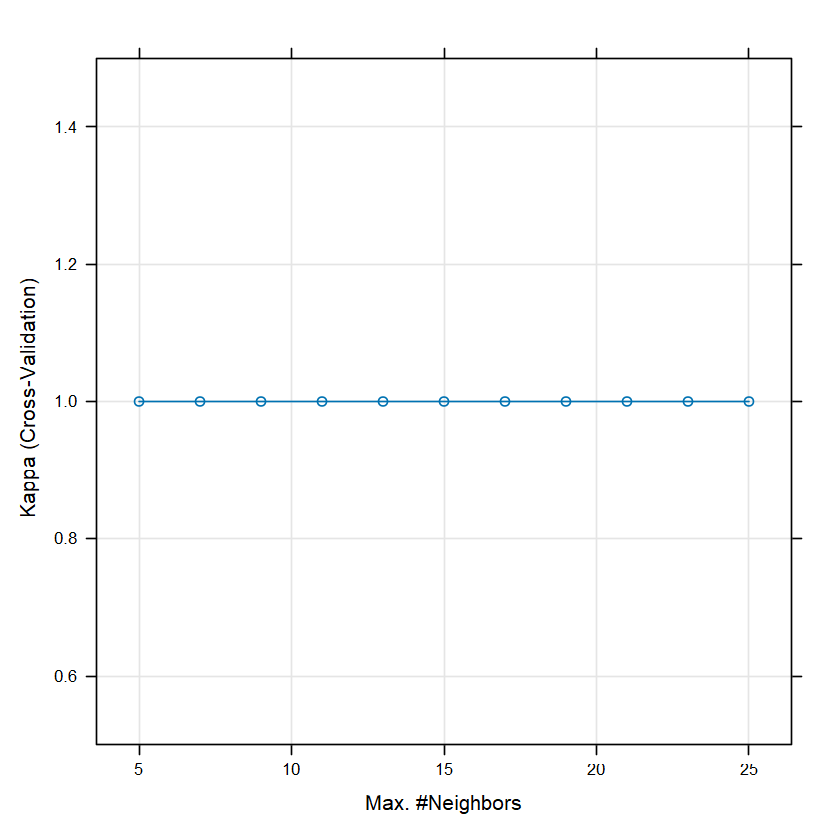

In [2]:
set.seed(123)
train_id <- createDataPartition(df$Mitigation_Action_Taken, p = 0.7, list = FALSE)
df.train <- df[train_id, ]
df.test  <- df[-train_id, ]

df.train$Cost..USD....per.Kg <- log(df.train$Cost..USD....per.Kg + 1)
df.test$Cost..USD....per.Kg  <- log(df.test$Cost..USD....per.Kg  + 1)

zscore <- preProcess(
  df.train[, c("Geopolitical_Risk_Index", "Weather_Severity_Index",
               "Inflation_Rate_Pct", "Cost..USD....per.Kg", "Delay_Days")],
  method = c("center", "scale")
)

norm_cols <- c("Geopolitical_Risk_Index.n", "Weather_Severity_Index.n",
               "Inflation_Rate_Pct.n", "Delay_Days.n", "Cost..USD....per.Kg.n")

df.train[norm_cols] <- predict(
  zscore, df.train[, c("Geopolitical_Risk_Index", "Weather_Severity_Index",
                       "Inflation_Rate_Pct", "Delay_Days", "Cost..USD....per.Kg")]
)

df.test[norm_cols] <- predict(
  zscore, df.test[, c("Geopolitical_Risk_Index", "Weather_Severity_Index",
                      "Inflation_Rate_Pct", "Delay_Days", "Cost..USD....per.Kg")]
)

k.value <- 5
disfun  <- 2
comfun  <- "rectangular"

base.knn <- kknn(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index.n + Weather_Severity_Index.n +
    Inflation_Rate_Pct.n + Cost..USD....per.Kg.n + Delay_Days.n + Route_Type + Product_Category + Transportation_Mode + Disruption_Event,
  train    = df.train,
  test     = df.test,
  k        = k.value,
  distance = disfun,
  kernel   = comfun
)

df.test$pred.knn.base <- fitted(base.knn)

table(Predicted = df.test$pred.knn.base, Actual = df.test$Mitigation_Action_Taken)
accuracy.knn.base <- mean(df.test$pred.knn.base == df.test$Mitigation_Action_Taken)
cat("Base kNN Accuracy:", accuracy.knn.base, "\n")

confusionMatrix(df.test$pred.knn.base, df.test$Mitigation_Action_Taken)

ctrl <- trainControl(method = "cv", number = 5)

tunegrid <- expand.grid(
  kmax     = seq(5, 25, by = 2),
  distance = c(2),
  kernel   = c("rectangular")
)

set.seed(42)
cv.fit.knn <- train(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index.n + Weather_Severity_Index.n +
    Inflation_Rate_Pct.n + Cost..USD....per.Kg.n + Delay_Days.n + Disruption_Event +
    Route_Type + Product_Category + Transportation_Mode,
  data      = df.train,
  method    = "kknn",
  tuneGrid  = tunegrid,
  trControl = ctrl,
  metric    = "Kappa"
)

print(cv.fit.knn)
plot(cv.fit.knn)

best.param.knn <- cv.fit.knn$bestTune
best.param.knn

best.knn <- kknn(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index.n + Weather_Severity_Index.n +
    Inflation_Rate_Pct.n + Cost..USD....per.Kg.n + Delay_Days.n + Disruption_Event +
    Route_Type + Product_Category + Transportation_Mode,
  train    = df.train,
  test     = df.test,
  k        = best.param.knn$kmax,
  distance = best.param.knn$distance,
  kernel   = as.character(best.param.knn$kernel)
)

df.test$pred.knn.best <- fitted(best.knn)

table(Predicted = df.test$pred.knn.best, Actual = df.test$Mitigation_Action_Taken)
accuracy.knn.best <- mean(df.test$pred.knn.best == df.test$Mitigation_Action_Taken)
cat("Best kNN Accuracy:", accuracy.knn.best, "\n")

confusionMatrix(df.test$pred.knn.best, df.test$Mitigation_Action_Taken)


The kNN classification model demonstrated that combinations of operational and disruption-related variables could effectively distinguish between different mitigation response patterns.


# Decision Tree Analysis

Decision trees were used to identify the strongest branching variables associated with mitigation actions. This approach improved interpretability by visually displaying the sequence of conditions associated with different corrective supply chain responses.


Call:
rpart(formula = Mitigation_Action_Taken ~ Geopolitical_Risk_Index + 
    Weather_Severity_Index + Inflation_Rate_Pct + Cost..USD....per.Kg + 
    Delay_Days + Disruption_Event + Route_Type + Product_Category + 
    Transportation_Mode, data = df.train, method = "class", control = rpart.control(cp = 0.01, 
    split = "gini", minsplit = 20, minbucket = 10, maxdepth = 5))
  n= 905 

          CP nsplit  rel error     xerror        xstd
1 0.48373984      0 1.00000000 1.00000000 0.030455672
2 0.03252033      2 0.03252033 0.03252033 0.008057893
3 0.01000000      3 0.00000000 0.00000000 0.000000000

Variable importance
Cost..USD....per.Kg    Disruption_Event          Route_Type          Delay_Days 
                 22                  20                  18                  17 
   Product_Category Transportation_Mode 
                 14                   8 

Node number 1: 905 observations,    complexity param=0.4837398
  predicted class=Standard Shipping      expected loss=0.5436464 

                       Actual
Predicted               Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    99          0                 0
  Re-routing                                0        110                 0
  Standard Shipping                         0          0               176

Base Decision Tree Accuracy: 1 


Confusion Matrix and Statistics

                       Reference
Prediction              Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    99          0                 0
  Re-routing                                0        110                 0
  Standard Shipping                         0          0               176

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.9905, 1)
    No Information Rate : 0.4571     
    P-Value [Acc > NIR] : < 2.2e-16  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: Expedited Air Freight Class: Re-routing
Sensitivity                                1.0000            1.0000
Specificity                                1.0000            1.0000
Pos Pred Value                             1.

CART 

905 samples
  9 predictor
  3 classes: 'Expedited Air Freight', 'Re-routing', 'Standard Shipping' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 724, 723, 725, 725, 723 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa    
  0.001  0.9679002  0.9501672
  0.006  0.9701164  0.9536523
  0.011  0.9668197  0.9485049
  0.016  0.9525097  0.9261608
  0.021  0.9513924  0.9243178
  0.026  0.9425524  0.9107349
  0.031  0.9425524  0.9107349
  0.036  0.9425524  0.9107349
  0.041  0.9425524  0.9107349
  0.046  0.9425524  0.9107349

Kappa was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.006.


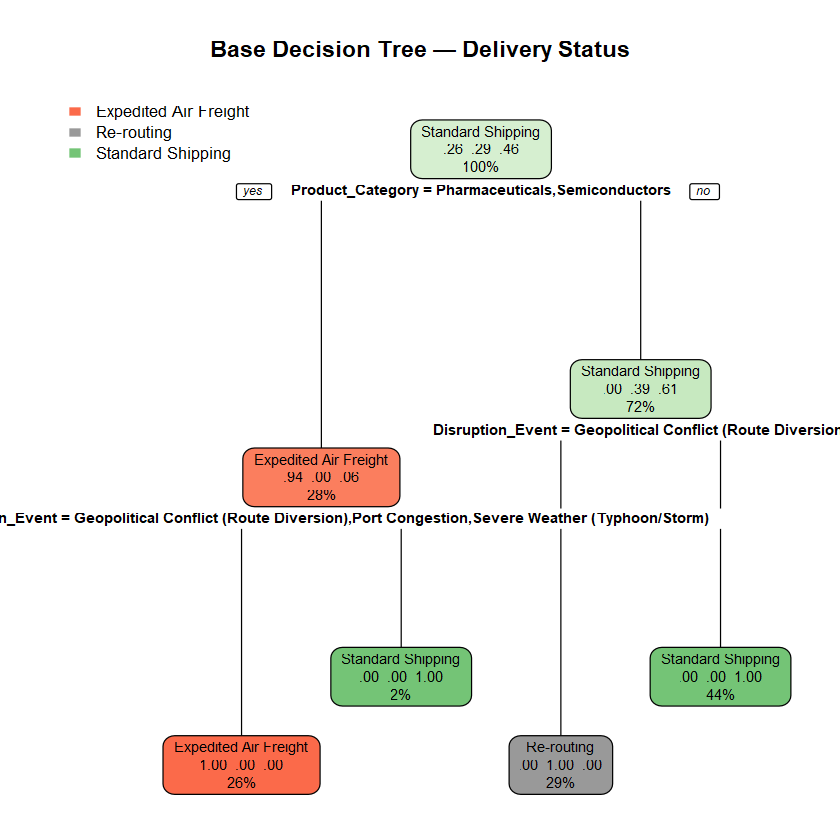

,cp
,<dbl>
2,0.006


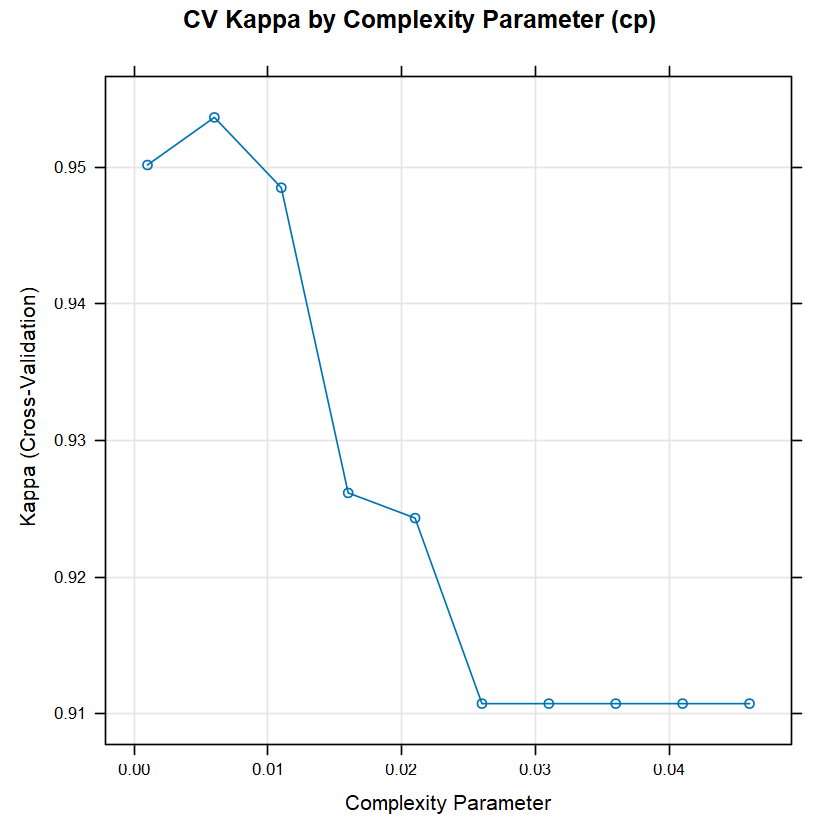

Call:
rpart(formula = Mitigation_Action_Taken ~ Geopolitical_Risk_Index + 
    Weather_Severity_Index + Inflation_Rate_Pct + Cost..USD....per.Kg + 
    Delay_Days + Disruption_Event + Route_Type + Product_Category + 
    Transportation_Mode, data = df.train, method = "class", control = rpart.control(cp = best.param.dt$cp, 
    split = "gini"))
  n= 905 

          CP nsplit  rel error     xerror        xstd
1 0.48373984      0 1.00000000 1.00000000 0.030455672
2 0.03252033      2 0.03252033 0.03252033 0.008057893
3 0.00600000      3 0.00000000 0.00000000 0.000000000

Variable importance
Cost..USD....per.Kg    Disruption_Event          Route_Type          Delay_Days 
                 22                  20                  18                  17 
   Product_Category Transportation_Mode 
                 14                   8 

Node number 1: 905 observations,    complexity param=0.4837398
  predicted class=Standard Shipping      expected loss=0.5436464  P(node) =1
    class counts:   2

                       Actual
Predicted               Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    99          0                 0
  Re-routing                                0        110                 0
  Standard Shipping                         0          0               176

Best Decision Tree Accuracy: 1 


Confusion Matrix and Statistics

                       Reference
Prediction              Expedited Air Freight Re-routing Standard Shipping
  Expedited Air Freight                    99          0                 0
  Re-routing                                0        110                 0
  Standard Shipping                         0          0               176

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.9905, 1)
    No Information Rate : 0.4571     
    P-Value [Acc > NIR] : < 2.2e-16  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: Expedited Air Freight Class: Re-routing
Sensitivity                                1.0000            1.0000
Specificity                                1.0000            1.0000
Pos Pred Value                             1.

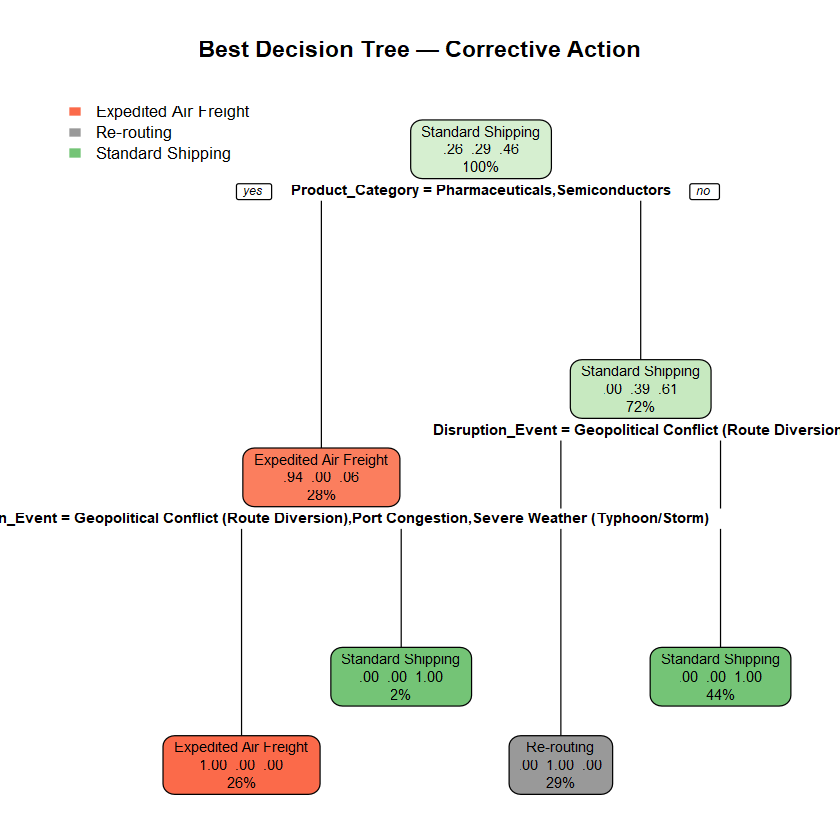

In [3]:
tree.base <- rpart(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost..USD....per.Kg + Delay_Days +
    Disruption_Event + Route_Type + Product_Category + Transportation_Mode,
  data    = df.train,
  method  = "class",
  control = rpart.control(
    cp        = 0.01,
    split     = "gini",
    minsplit  = 20,
    minbucket = 10,
    maxdepth  = 5
  )
)

rpart.plot(tree.base, main = "Base Decision Tree — Delivery Status")
summary(tree.base)

df.test$pred.dt.base <- predict(tree.base, df.test, type = "class")

table(Predicted = df.test$pred.dt.base, Actual = df.test$Mitigation_Action_Taken)
accuracy.dt.base <- mean(df.test$pred.dt.base == df.test$Mitigation_Action_Taken)
cat("Base Decision Tree Accuracy:", accuracy.dt.base, "\n")

confusionMatrix(df.test$pred.dt.base, df.test$Mitigation_Action_Taken)

ctrl <- trainControl(method = "cv", number = 5)

tunegrid <- expand.grid(
  cp = seq(0.001, 0.050, by = 0.005)
)

set.seed(42)
cv.fit.dt <- train(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost..USD....per.Kg + Delay_Days +
    Disruption_Event + Route_Type + Product_Category + Transportation_Mode,
  data      = df.train,
  method    = "rpart",
  tuneGrid  = tunegrid,
  trControl = ctrl,
  control   = rpart.control(split = "gini"),
  metric    = "Kappa"
)

print(cv.fit.dt)
plot(cv.fit.dt, main = "CV Kappa by Complexity Parameter (cp)")

best.param.dt <- cv.fit.dt$bestTune
best.param.dt

tree.best <- rpart(
  Mitigation_Action_Taken ~ Geopolitical_Risk_Index + Weather_Severity_Index +
    Inflation_Rate_Pct + Cost..USD....per.Kg + Delay_Days +
    Disruption_Event + Route_Type + Product_Category + Transportation_Mode,
  data    = df.train,
  method  = "class",
  control = rpart.control(
    cp    = best.param.dt$cp,
    split = "gini"
  )
)

rpart.plot(tree.best, main = "Best Decision Tree — Corrective Action")
summary(tree.best)

df.test$pred.dt.best <- predict(tree.best, df.test, type = "class")

table(Predicted = df.test$pred.dt.best, Actual = df.test$Mitigation_Action_Taken)
accuracy.dt.best <- mean(df.test$pred.dt.best == df.test$Mitigation_Action_Taken)
cat("Best Decision Tree Accuracy:", accuracy.dt.best, "\n")

confusionMatrix(df.test$pred.dt.best, df.test$Mitigation_Action_Taken)


The decision tree analysis revealed that disruption event and shipment industry were among the strongest predictors of which mitigation actions organizations implemented during shipment disruptions.


# Model Summary Comparison

The final comparison evaluates how effectively the kNN and decision tree models classified mitigation actions across the dataset.


In [4]:
knn.cm  <- confusionMatrix(df.test$pred.knn.best, df.test$Mitigation_Action_Taken)
base.cm <- confusionMatrix(df.test$pred.dt.base,  df.test$Mitigation_Action_Taken)
best.cm <- confusionMatrix(df.test$pred.dt.best,  df.test$Mitigation_Action_Taken)

cat("\n=== Best kNN Model Performance ===\n")
cat("Accuracy:    ", knn.cm$overall['Accuracy'],    "\n")
cat("Kappa:       ", knn.cm$overall['Kappa'],       "\n")
cat("Sensitivity: ", knn.cm$byClass['Sensitivity'], "\n")
cat("Specificity: ", knn.cm$byClass['Specificity'], "\n")

cat("\n=== Base Decision Tree Performance ===\n")
cat("Accuracy:    ", base.cm$overall['Accuracy'],    "\n")
cat("Kappa:       ", base.cm$overall['Kappa'],       "\n")
cat("Sensitivity: ", base.cm$byClass['Sensitivity'], "\n")
cat("Specificity: ", base.cm$byClass['Specificity'], "\n")

cat("\n=== Best Decision Tree Performance ===\n")
cat("Accuracy:    ", best.cm$overall['Accuracy'],    "\n")
cat("Kappa:       ", best.cm$overall['Kappa'],       "\n")
cat("Sensitivity: ", best.cm$byClass['Sensitivity'], "\n")
cat("Specificity: ", best.cm$byClass['Specificity'], "\n")

comparison <- data.frame(
  Model       = c("Best kNN", "Base Decision Tree", "Best Decision Tree"),
  Accuracy    = c(knn.cm$overall['Accuracy'], base.cm$overall['Accuracy'], best.cm$overall['Accuracy']),
  Kappa       = c(knn.cm$overall['Kappa'], base.cm$overall['Kappa'], best.cm$overall['Kappa']),
  Sensitivity = c(knn.cm$byClass['Sensitivity'], base.cm$byClass['Sensitivity'], best.cm$byClass['Sensitivity']),
  Specificity = c(knn.cm$byClass['Specificity'], base.cm$byClass['Specificity'], best.cm$byClass['Specificity'])
)

print(comparison)



=== Best kNN Model Performance ===
Accuracy:     0.8961039 
Kappa:        0.8357579 
Sensitivity:  NA 
Specificity:  NA 

=== Base Decision Tree Performance ===
Accuracy:     1 
Kappa:        1 
Sensitivity:  NA 
Specificity:  NA 

=== Best Decision Tree Performance ===
Accuracy:     1 
Kappa:        1 
Sensitivity:  NA 
Specificity:  NA 
               Model  Accuracy     Kappa Sensitivity Specificity
1           Best kNN 0.8961039 0.8357579          NA          NA
2 Base Decision Tree 1.0000000 1.0000000          NA          NA
3 Best Decision Tree 1.0000000 1.0000000          NA          NA


The final comparison showed that both the kNN and decision tree models successfully identified meaningful patterns associated with corrective supply chain responses.


# Summary

- Disruption event emerged as one of the strongest predictors of mitigation actions taken during shipment delays.
- Geopolitical conflict-related disruptions were strongly associated with more intensive corrective supply chain responses.
- Route type and transportation mode also contributed to mitigation decision patterns across the dataset.
- The decision tree model improved interpretability by visually identifying the operational conditions associated with different mitigation actions.
- The kNN model demonstrated that combinations of operational and disruption-related variables collectively influenced corrective supply chain decisions.
- Overall, the analysis showed that disruption characteristics and operational routing factors played a major role in determining how organizations responded to shipment delays.
